# S1 Deforestation Tracker

In [1]:
import ee
import geemap
from datetime import datetime
import os
import sys
import pandas as pd

import geopandas as gpd
import rioxarray as rxr
import dask
from dask import compute
import xarray as xr
import numpy as np
import dask.array as da
import zarr
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from rasterio.crs import CRS

from scipy.ndimage import uniform_filter
from scipy.ndimage import convolve
from scipy.interpolate import interp1d
from scipy import ndimage as ndi
from shapely.geometry import mapping

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from dask.diagnostics import ProgressBar    

from numba import njit


# Base path
base_path = os.path.expanduser("~/data/LEON_P6_forest-agri-change/")

In [ ]:
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='xx')

## Orbit test
- Check which orbits exist over the area of interest
- Visualise first and last scene

#### Check Orbits

In [ ]:
# Load AOI
ROI_FILE = base_path + 'area/counties_bugoma_cut_4326.gpkg'

gdf = gpd.read_file(ROI_FILE)
if gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs('EPSG:4326')

geom = gdf.unary_union
roi = ee.Geometry.Polygon(list(mapping(geom)['coordinates'][0]))

# Check ALL available orbits for your area
s1_all = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2025-01-01')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
    .select(['VH']))

# Get unique orbit numbers
orbits = s1_all.aggregate_array('relativeOrbitNumber_start').distinct().getInfo()
print(f"Available DESCENDING orbits: {sorted(orbits)}")

# Count images per orbit
for orbit in sorted(orbits):
    s1_orbit = s1_all.filter(ee.Filter.eq('relativeOrbitNumber_start', orbit))
    n_images = s1_orbit.size().getInfo()
    print(f"  Orbit {orbit}: {n_images} images")

# Also check ASCENDING
s1_asc = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2025-01-01')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .select(['VH']))

orbits_asc = s1_asc.aggregate_array('relativeOrbitNumber_start').distinct().getInfo()
print(f"\nAvailable ASCENDING orbits: {sorted(orbits_asc)}")

for orbit in sorted(orbits_asc):
    s1_orbit = s1_asc.filter(ee.Filter.eq('relativeOrbitNumber_start', orbit))
    n_images = s1_orbit.size().getInfo()
    print(f"  Orbit {orbit}: {n_images} images")

### Visualise test scenes first and last

In [ ]:
"""
S1 FIRST & LAST VH
==================================
Load first and last Sentinel-1 VH images as NumPy arrays
"""


# ---------------- CONFIG ----------------
BBOX = [30.63444328, 1.07092791, 31.22295212, 1.53564323]
START_DATE = '2020-01-01'
END_DATE   = '2025-01-01'
ORBIT = 101
PASS = 'ASCENDING'
SCALE = 30

roi = ee.Geometry.Rectangle(BBOX)

# ---------------- COLLECTION ----------------
s1 = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', PASS))
    .filter(ee.Filter.eq('relativeOrbitNumber_start', ORBIT))
    .select('VH')
    .sort('system:time_start')
)

n = s1.size().getInfo()
if n == 0:
    raise RuntimeError("No images found")

imgs = s1.toList(n)

dates = [
    datetime.fromtimestamp(t / 1000)
    for t in s1.aggregate_array('system:time_start').getInfo()
]

# ---------------- LOAD FIRST & LAST ----------------
first_img = ee.Image(imgs.get(0)).clip(roi)
last_img  = ee.Image(imgs.get(n - 1)).clip(roi)

first = geemap.ee_to_numpy(first_img, region=roi, scale=SCALE)[:, :, 0]
last  = geemap.ee_to_numpy(last_img,  region=roi, scale=SCALE)[:, :, 0]

first_date = dates[0].strftime('%Y-%m-%d')
last_date  = dates[-1].strftime('%Y-%m-%d')

print(f"Loaded FIRST: {first_date}")
print(f"Loaded LAST : {last_date}")
print(f"Shape: {first.shape}")

In [ ]:
# ---------------- VISUALISE ----------------

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

im0 = axes[0].imshow(first, cmap='gray', vmin=-25, vmax=-5)
axes[0].set_title(f'FIRST: {first_date}', fontsize=10, fontweight='bold')
axes[0].axis('off')

im1 = axes[1].imshow(last, cmap='gray', vmin=-25, vmax=-5)
axes[1].set_title(f'LAST: {last_date}', fontsize=10, fontweight='bold')
axes[1].axis('off')

cbar = fig.colorbar(im1, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label('VH (dB)')

plt.show()

## Download S1 from GEE locally

In [ ]:
"""
S1 DOWNLOAD complete time series - ORBIT 101 (ASCENDING)
===========================================================
"""

# ===================== CONFIG =====================
ROI_FILE = base_path + 'area/counties_bugoma_cut_4326.gpkg'
OUTPUT_DIR = base_path + 's1_timeseries'
SCALE = 30
ORBIT = 101

# ===================== LOAD ROI =====================
gdf = gpd.read_file(ROI_FILE, layer='counties_bugoma_cut_4326')
if gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs('EPSG:4326')

geom = gdf.union_all()
roi = ee.Geometry.Polygon(list(mapping(geom)['coordinates'][0]))
bounds = gdf.total_bounds

# ===================== GET S1 COLLECTION =====================
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2025-01-01')  # Adjust date as needed
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')) # Adjust orbit pass as needed
    .filter(ee.Filter.eq('relativeOrbitNumber_start', ORBIT))
    .select(['VH'])
    .map(lambda img: img.clip(roi))
    .sort('system:time_start'))

n_images = s1.size().getInfo()
dates = [np.datetime64(datetime.fromtimestamp(d/1000)) 
         for d in s1.aggregate_array('system:time_start').getInfo()]

print(f"Downloading {n_images} images from orbit {ORBIT} (ASCENDING)")
print(f"Date range: {dates[0]} to {dates[-1]}")

# ===================== DOWNLOAD =====================
img_list = s1.toList(n_images)
first_img = ee.Image(img_list.get(0))
projection = first_img.select('VH').projection()

vh_first = geemap.ee_to_numpy(
    first_img.select('VH').reproject(crs=projection, scale=SCALE),
    region=roi, scale=SCALE
)
if len(vh_first.shape) == 3:
    vh_first = vh_first[:, :, 0]

ny, nx = vh_first.shape
print(f"Grid: {ny}×{nx} pixels")

all_data = np.zeros((ny, nx, n_images), dtype=np.float32)
all_data[:, :, 0] = vh_first

for i in range(1, n_images):
    if i % 10 == 0:
        print(f"  Progress: {i}/{n_images}")
    
    try:
        img = ee.Image(img_list.get(i))
        vh = geemap.ee_to_numpy(
            img.select('VH').reproject(crs=projection, scale=SCALE),
            region=roi, scale=SCALE
        )
        if len(vh.shape) == 3:
            vh = vh[:, :, 0]
        all_data[:, :, i] = vh if vh.shape == (ny, nx) else np.nan
    except:
        all_data[:, :, i] = np.nan

# Flip vertically for standard raster orientation
all_data = np.flip(all_data, axis=0)

# ===================== SAVE =====================
os.makedirs(OUTPUT_DIR, exist_ok=True)

lons = np.linspace(bounds[0], bounds[2], nx)
lats = np.linspace(bounds[3], bounds[1], ny)

ds = xr.Dataset(
    {'VH': (['y', 'x', 'time'], all_data)},
    coords={'x': lons, 'y': lats, 'time': dates},
    attrs={'orbit': ORBIT, 'pass_direction': 'ASCENDING', 'scale': SCALE}
)

output_file = f"{OUTPUT_DIR}/s1_orbit101.zarr"
ds.to_zarr(output_file, mode='w', encoding={'VH': {'chunks': (ny, nx, 50)}})

print(f"\n✓ Saved: {output_file}")
print(f"  Shape: {all_data.shape}")
print(f"  Coverage: {np.sum(~np.isnan(all_data) & (all_data != 0)) / all_data.size * 100:.1f}%")
print("\n Download complete! Ready for filtering and analysis.")

## Load Zarr and reproject

In [ ]:
ds = xr.open_zarr('/data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_orbit101.zarr')
ds

In [ ]:
# transpose, reproject and plot
ds = ds.transpose("time", "y", "x")
ds = ds.rio.write_crs("EPSG:4326")
ds_utm = ds.rio.reproject("EPSG:32636")

print(ds_utm.rio.crs)
ds_utm.VH.isel(time=5).plot(cmap='gray', vmin=-25, vmax=-5, figsize=(10, 8))

In [ ]:
# write zarr reprojected
ds_utm.to_zarr("/data/LEON/P6_forest_agri_uganda/s1_timeseries/s1_orbit101_32636.zarr", mode="w", consolidated=True)


# Main Workflow

## Load Data

In [2]:
import xarray, zarr
print(xarray.__version__, zarr.__version__)

2026.2.0 3.1.5


In [25]:
"""
COMPLETE LOCAL PROCESSING WORKFLOW
===================================
Apply forest mask, filters, and logistic fitting
"""

# ===================== LOAD DATA =====================
print("Loading complete time series...")
zarr_complete = base_path + "s1_timeseries/s1_orbit101_32636.zarr"

ds = xr.open_zarr(zarr_complete, consolidated=False)

print(f"Dataset: {ds.dims}")
print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")

vh_array = ds['VH'].values 
print(f"VH shape: {vh_array.shape}")

# ===================== LOAD AND APPLY FOREST MASK =====================
print("\nLoading forest mask...")
forest_mask_path = base_path + "forest_extent_bugoma_2020_32636.tif"

with rasterio.open(forest_mask_path) as src:
    forest_array = src.read(1)
    forest_transform = src.transform
    forest_crs = src.crs

print(f"Forest mask shape: {forest_array.shape}")
print(f"Forest pixels: {(forest_array == 1).sum():,}")

# Resample forest mask to match S1 grid
from scipy.ndimage import zoom

if forest_array.shape != vh_array.shape[:2]:
    print(f"Resampling forest mask from {forest_array.shape} to {vh_array.shape[:2]}...")
    zoom_factors = (vh_array.shape[0] / forest_array.shape[0], 
                    vh_array.shape[1] / forest_array.shape[1])
    forest_resampled = zoom(forest_array, zoom_factors, order=0)  # Nearest neighbor
else:
    forest_resampled = forest_array

print(f"Resampled forest mask: {forest_resampled.shape}")
print(f"Forest pixels in S1 grid: {(forest_resampled == 1).sum():,}")

# Apply mask to data (set non-forest to NaN)
vh_masked = vh_array.copy()
vh_masked[forest_resampled != 1, :] = np.nan

print(f"✓ Forest mask applied")

Loading complete time series...
Dataset: FrozenMappingWarningOnValuesAccess({'time': 152, 'y': 1716, 'x': 2186})
Date range: 2020-01-02T16:13:18.000000000 to 2024-12-30T16:13:34.000000000
VH shape: (152, 1716, 2186)

Loading forest mask...
Forest mask shape: (5284, 7508)
Forest pixels: 6,068,867
Resampling forest mask from (5284, 7508) to (152, 1716)...
Resampled forest mask: (152, 1716)
Forest pixels in S1 grid: 39,557
✓ Forest mask applied


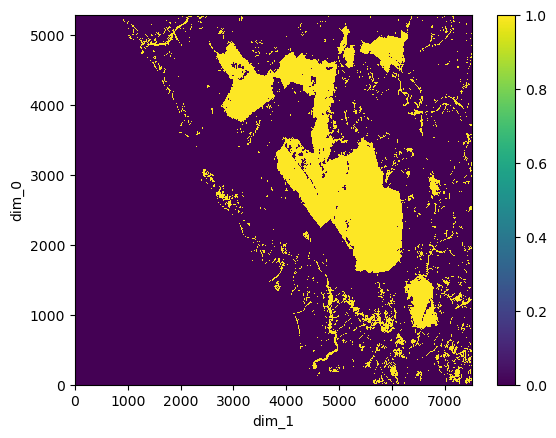

: 

In [ ]:
xr.DataArray(forest_array).plot()

## Speckle filter

In [2]:
"""
Speckle Filtering Pipeline
==================================================
1. Load S1 data (Zarr, lazy)
2. Apply Lee filter (5x5, radius 2.0) 
3. Apply Quegan & Yu multitemporal (5 temporal window, 5x5 spatial window)
4. Save filtered result to Zarr (chunked, consolidated)
"""

# ===================== 0. CONFIG =====================
ZARR_IN = base_path + "s1_timeseries/s1_orbit101_32636.zarr"
ZARR_OUT = base_path + "s1_timeseries/s1_filtered_k5.zarr"

# Target Dask chunks (tune if needed)
TARGET_CHUNKS = {"time": 10, "y": 256, "x": 256}

# Filtering params
RADIUS = 2               # 5x5 circular kernel
WINDOW = 5               # Quegan & Yu temporal window
CU_SQUARED = 0.25        # Lee parameter (4-look GRD typical)

# ===================== 1. LOAD DATA (LAZY) =====================
print("=" * 60)
print("STEP 1: LOADING DATA (ZARR, lazy)")
print("=" * 60)

ds = xr.open_zarr(ZARR_IN, consolidated=True, chunks="auto")  
vh = ds["VH"].transpose("time", "y", "x")                     
vh = vh.chunk(TARGET_CHUNKS)                                 

print("VH:")
print(vh)
print(f"Date range: {ds.time[0].values} → {ds.time[-1].values}")

# ===================== 2. SPATIAL KERNEL =====================
def create_circular_kernel(radius=2.0):
    size = int(radius * 2 + 1)
    center = radius
    y, x = np.ogrid[-center:size-center, -center:size-center]
    mask = (x**2 + y**2) <= radius**2
    kernel = mask.astype(np.float32)
    return kernel / kernel.sum()

KERNEL_5x5 = create_circular_kernel(RADIUS)

# ===================== 3. DASK-AWARE LEE FILTER =====================
print("\n" + "=" * 60)
print(f"STEP 2: APPLYING LEE FILTER (5x5, radius {RADIUS})")
print("=" * 60)

def lee_3d(block, kernel, cu_squared=0.25):
    """
    Apply 2D Lee filter independently to each time slice of a 3D block: (T, Y, X).
    This runs inside a single Dask task (NumPy function), with spatial halos provided by map_overlap.
    """
    block = block.astype(np.float32, copy=False)
    T, Y, X = block.shape
    out = np.empty_like(block, dtype=np.float32)

    for t in range(T):
        img = block[t]
        # Local stats via circular kernel
        mean = convolve(img, kernel, mode="reflect")
        sqr_mean = convolve((img * img), kernel, mode="reflect")
        var = np.maximum(sqr_mean - mean * mean, 0.0)

        ci2 = var / (mean * mean + 1e-10)
        w = np.clip((ci2 - cu_squared) / (ci2 + 1e-10), 0.0, 1.0)
        out[t] = mean + w * (img - mean)

    return out

# Apply Lee over (time, y, x) with spatial halos only
vh_arr = vh.data  # dask array (t, y, x)
vh_lee_arr = da.map_overlap(
    lee_3d,
    vh_arr,
    depth=(0, RADIUS, RADIUS),                     # no time overlap, spatial halos only
    boundary=("none", "reflect", "reflect"),       # don't pad time; reflect spatial edges
    dtype=np.float32,
    kernel=KERNEL_5x5,
    cu_squared=CU_SQUARED,
)

vh_lee = xr.DataArray(
    vh_lee_arr,
    dims=("time", "y", "x"),
    coords={"time": vh.time, "y": vh.y, "x": vh.x},
    name="VH_lee",
    attrs={"description": f"Lee filter (radius={RADIUS}, circular 5x5)"}
)

# ===================== 4. DASK-AWARE QUEGAN & YU =====================
print("\n" + "=" * 60)
print(f"STEP 3: APPLYING QUEGAN & YU MULTITEMPORAL FILTER (window={WINDOW})")
print("=" * 60)

HALF = WINDOW // 2

def qy_3d(block, kernel, half_win):
    """
    Quegan & Yu across time with spatial means:
      For each time t in the block:
        num = Σ (I / μ)
        den = Σ (1 / μ)
        out = num / den
      where μ = spatial mean (convolve with circular kernel)
    The block includes time halos; this function computes per-time results and
    returns the full block. map_overlap trims halos automatically.
    """
    block = block.astype(np.float32, copy=False)
    T, Y, X = block.shape
    out = np.empty_like(block, dtype=np.float32)

    for t in range(T):
        t0 = max(0, t - half_win)
        t1 = min(T, t + half_win + 1)

        num = 0.0
        den = 0.0
        for tt in range(t0, t1):
            img = block[tt]
            mu = convolve(img, kernel, mode="reflect")
            num += img / (mu + 1e-10)
            den += 1.0 / (mu + 1e-10)
        out[t] = num / (den + 1e-10)

    return out

vh_filtered_arr = da.map_overlap(
    qy_3d,
    vh_lee.data,
    depth=(HALF, RADIUS, RADIUS),                   # temporal + spatial halos
    boundary=("none", "reflect", "reflect"),        # no time padding beyond global
    dtype=np.float32,
    kernel=KERNEL_5x5,
    half_win=HALF,
)

vh_filtered = xr.DataArray(
    vh_filtered_arr,
    dims=("time", "y", "x"),
    coords={"time": vh.time, "y": vh.y, "x": vh.x},
    name="VH_filtered",
    attrs={
        "description": "Quegan & Yu multitemporal (window=5, spatial radius=2)",
        "temporal_window": WINDOW,
        "spatial_radius": float(RADIUS),
    }
)

# ===================== 5. PACKAGE + SAVE TO ZARR =====================
print("\n" + "=" * 60)
print("STEP 4: SAVING FILTERED DATA TO ZARR (this triggers computation)")
print("=" * 60)

ds_out = xr.Dataset(
    data_vars={
        "VH_filtered": vh_filtered,
        "VH_lee": vh_lee,
        "VH_raw": vh.astype(np.float32),
    },
    coords={"time": vh.time, "y": vh.y, "x": vh.x},
    attrs={
        "description": "Filtered S1 time series",
        "filters": f"Lee (5x5, r={RADIUS}) + Quegan & Yu (window={WINDOW})",
        "lee_reference": "Lee, J.-S. (1981). CGIP 15, 380–389",
        "note": "Dask-aware pipeline with spatial/temporal overlap; Zarr consolidated.",
    },
).chunk(TARGET_CHUNKS)


encoding = {}

# Progress bar for local runs (remove if using dask.distributed dashboard)
with ProgressBar():
    ds_out.to_zarr(ZARR_OUT, mode="w", consolidated=True, encoding=encoding)

print(f"✓ Saved to: {ZARR_OUT}")

# ===================== SUMMARY =====================
print("\n" + "=" * 60)
print("FILTERING COMPLETE!")
print("=" * 60)
print("Applied filters:")
print(f"  1. Lee filter (Lee, 1981)")
print(f"     - Circular window: radius {RADIUS} (5×5)")
print("     - Reduces speckle noise")
print()
print("  2. Quegan & Yu multitemporal filter")
print(f"     - Temporal window: {WINDOW} images (t-2, t-1, t, t+1, t+2)")
print(f"     - Spatial window: 5×5 (radius {RADIUS})")
print("     - Reduces temporal noise")
print()
print(f"Output saved to: {ZARR_OUT}")
print("Ready for deforestation analysis!")

STEP 1: LOADING DATA (ZARR, lazy)
VH:
<xarray.DataArray 'VH' (time: 152, y: 1716, x: 2186)> Size: 2GB
dask.array<rechunk-merge, shape=(152, 1716, 2186), dtype=float32, chunksize=(10, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2020-01-02T16:13:18 ... 2024-12-30T16:...
  * y        (y) float64 14kB 1.699e+05 1.699e+05 ... 1.185e+05 1.184e+05
  * x        (x) float64 17kB 2.367e+05 2.368e+05 ... 3.023e+05 3.023e+05
Attributes:
    grid_mapping:  spatial_ref
Date range: 2020-01-02T16:13:18.000000000 → 2024-12-30T16:13:34.000000000

STEP 2: APPLYING LEE FILTER (5x5, radius 2)

STEP 3: APPLYING QUEGAN & YU MULTITEMPORAL FILTER (window=5)

STEP 4: SAVING FILTERED DATA TO ZARR (this triggers computation)


/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


[########################################] | 100% Completed | 97.81 s
✓ Saved to: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered_k5.zarr

FILTERING COMPLETE!
Applied filters:
  1. Lee filter (Lee, 1981)
     - Circular window: radius 2 (5×5)
     - Reduces speckle noise

  2. Quegan & Yu multitemporal filter
     - Temporal window: 5 images (t-2, t-1, t, t+1, t+2)
     - Spatial window: 5×5 (radius 2)
     - Reduces temporal noise

Output saved to: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered_k5.zarr
Ready for deforestation analysis!


### VIS Speckle filtered dataset

Loading filtered data...
<xarray.Dataset> Size: 7GB
Dimensions:      (time: 152, y: 1716, x: 2186)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2020-01-02T16:13:18 ... 2024-12-30...
  * y            (y) float64 14kB 1.699e+05 1.699e+05 ... 1.185e+05 1.184e+05
  * x            (x) float64 17kB 2.367e+05 2.368e+05 ... 3.023e+05 3.023e+05
Data variables:
    VH_filtered  (time, y, x) float32 2GB dask.array<chunksize=(30, 768, 768), meta=np.ndarray>
    VH_lee       (time, y, x) float32 2GB dask.array<chunksize=(30, 768, 768), meta=np.ndarray>
    VH_raw       (time, y, x) float32 2GB dask.array<chunksize=(30, 768, 768), meta=np.ndarray>
Attributes:
    description:    Filtered S1 time series
    filters:        Lee (5x5, r=2) + Quegan & Yu (window=5)
    lee_reference:  Lee, J.-S. (1981). CGIP 15, 380–389
    note:           Dask-aware pipeline with spatial/temporal overlap; Zarr c...
Timestamp: 2022-11-23T16:13:36.000000000
Zoom region shape: (100, 100)


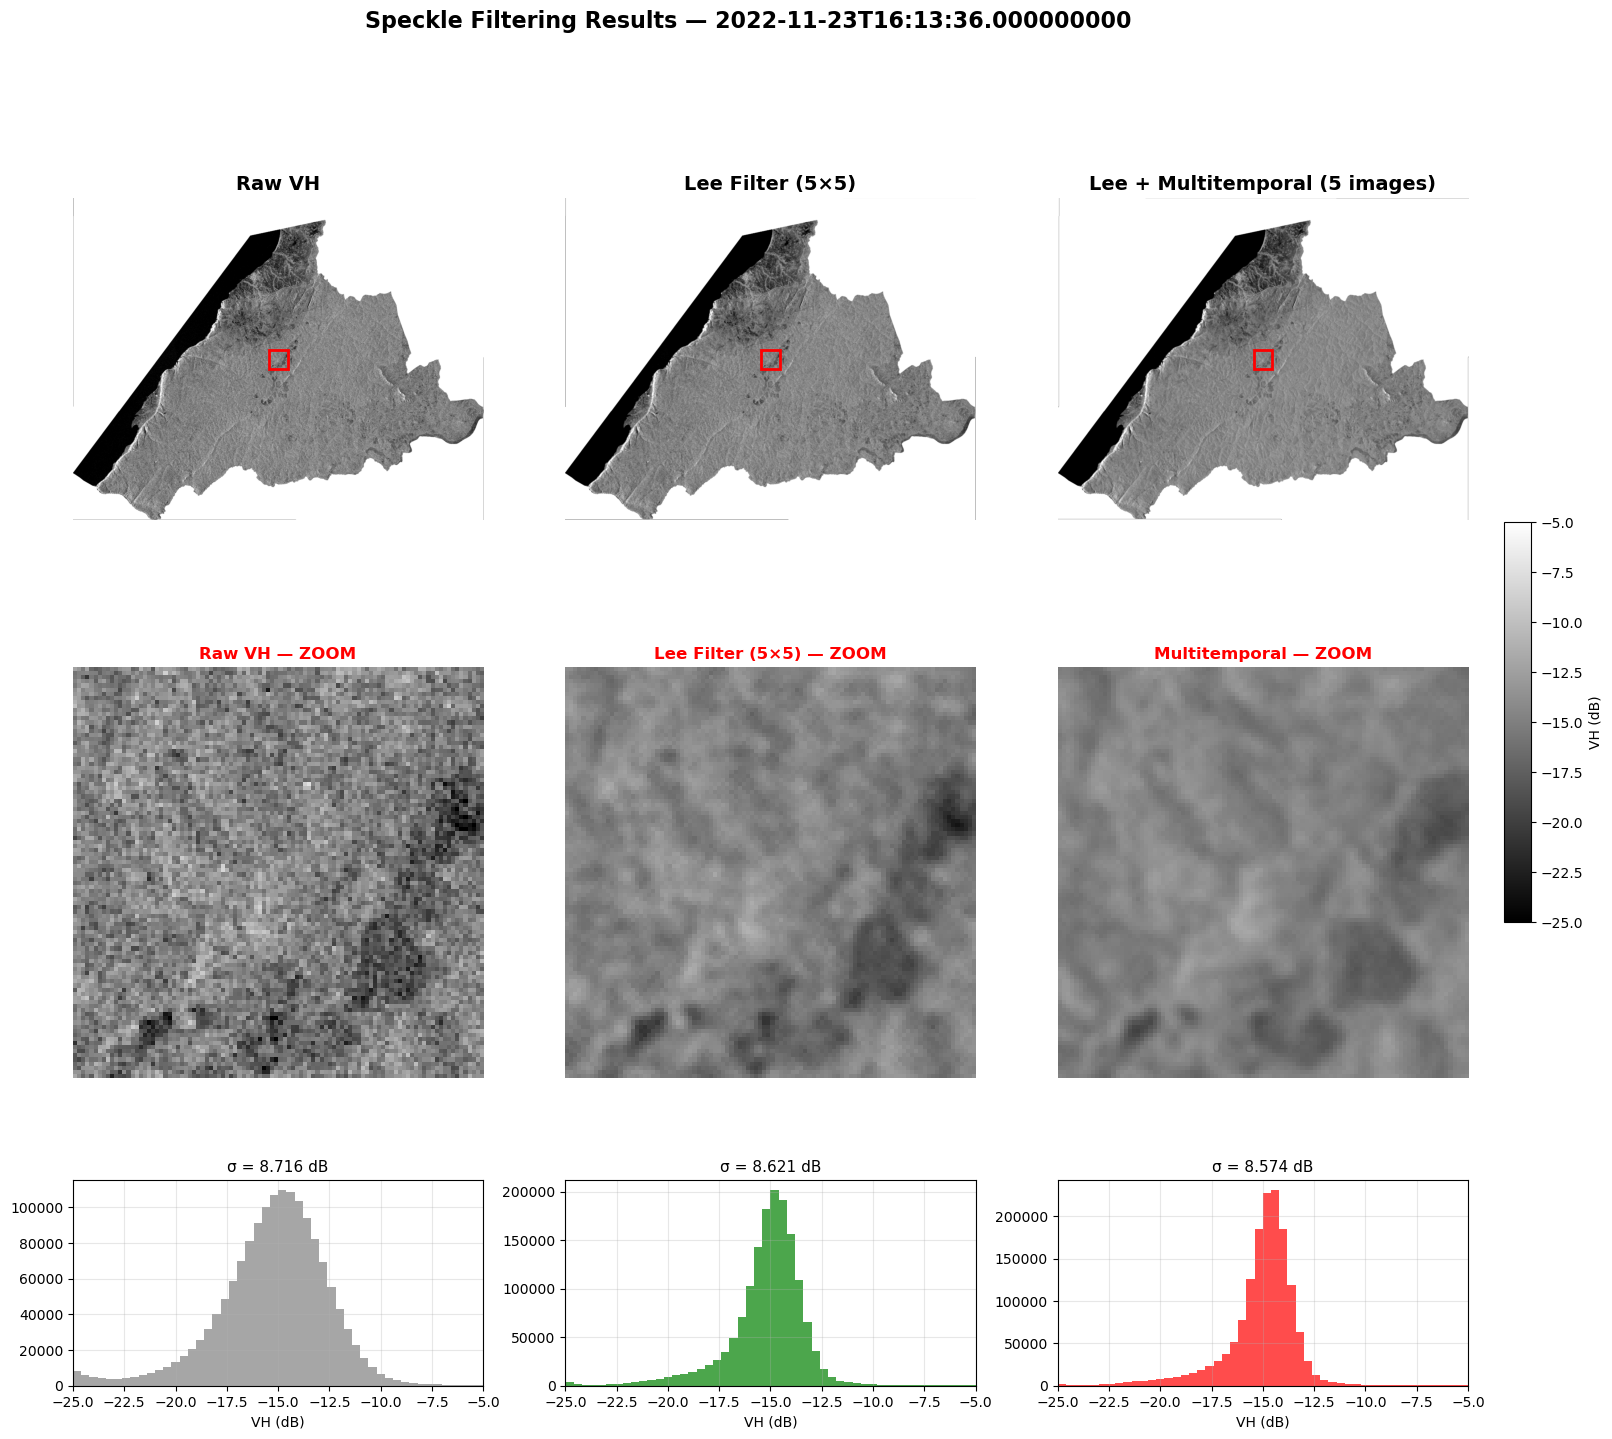


📊 SPECKLE REDUCTION (lower σ = better)

Full image:
  Raw:           σ = 8.716 dB
  Lee Filter:    σ = 8.621 dB  (1.1% reduction)
  Multitemporal: σ = 8.574 dB  (1.6% reduction)

Zoomed region:
  Raw:           σ = 2.301 dB
  Lee Filter:    σ = 1.514 dB  (34.2% reduction)
  Multitemporal: σ = 1.134 dB  (50.7% reduction)

✓ Filters successfully reduced speckle noise!


In [3]:
"""
Visualise Speckle Filtered Datasets
=====================================================
"""

# ===================== LOAD FILTERED DATA =====================
print("Loading filtered data...")

zarr_out = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered_k5.zarr"

ds = xr.open_zarr(
    zarr_out,
    consolidated=True,
    chunks="auto"
)

print(ds)

# Pick a middle timestamp
t = 87
print(f"Timestamp: {ds.time[t].values}")

# Slice FIRST (cheap), then materialize
vh_raw = ds["VH_raw"].isel(time=t).values
vh_lee = ds["VH_lee"].isel(time=t).values
vh_filtered = ds["VH_filtered"].isel(time=t).values

# ===================== EXTRACT ZOOM REGION =====================
ny, nx = vh_raw.shape
center_y, center_x = ny // 2, nx // 2
size = 50  # half-size → 100×100 window

y_start = max(center_y - size, 0)
y_end   = min(center_y + size, ny)
x_start = max(center_x - size, 0)
x_end   = min(center_x + size, nx)

vh_raw_zoom = vh_raw[y_start:y_end, x_start:x_end]
vh_lee_zoom = vh_lee[y_start:y_end, x_start:x_end]
vh_filtered_zoom = vh_filtered[y_start:y_end, x_start:x_end]

print(f"Zoom region shape: {vh_raw_zoom.shape}")

# ===================== PLOT =====================
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(
    3, 3,
    height_ratios=[2, 2, 1],
    hspace=0.3,
    wspace=0.2
)

vmin, vmax = -25, -5

# ---------- ROW 1: FULL IMAGES ----------
def plot_full(ax, img, title):
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    rect = plt.Rectangle(
        (x_start, y_start),
        x_end - x_start,
        y_end - y_start,
        fill=False,
        color="red",
        linewidth=2
    )
    ax.add_patch(rect)

ax00 = fig.add_subplot(gs[0, 0])
plot_full(ax00, vh_raw, "Raw VH")

ax01 = fig.add_subplot(gs[0, 1])
plot_full(ax01, vh_lee, "Lee Filter (5×5)")

ax02 = fig.add_subplot(gs[0, 2])
plot_full(ax02, vh_filtered, "Lee + Multitemporal (5 images)")

# ---------- ROW 2: ZOOMED IMAGES ----------
ax10 = fig.add_subplot(gs[1, 0])
ax10.imshow(vh_raw_zoom, cmap="gray", vmin=vmin, vmax=vmax)
ax10.set_title("Raw VH — ZOOM", fontsize=12, fontweight="bold", color="red")
ax10.axis("off")

ax11 = fig.add_subplot(gs[1, 1])
ax11.imshow(vh_lee_zoom, cmap="gray", vmin=vmin, vmax=vmax)
ax11.set_title("Lee Filter (5×5) — ZOOM", fontsize=12, fontweight="bold", color="red")
ax11.axis("off")

ax12 = fig.add_subplot(gs[1, 2])
im = ax12.imshow(vh_filtered_zoom, cmap="gray", vmin=vmin, vmax=vmax)
ax12.set_title("Multitemporal — ZOOM", fontsize=12, fontweight="bold", color="red")
ax12.axis("off")

# ---------- COLORBAR ----------
cbar_ax = fig.add_axes([0.92, 0.40, 0.015, 0.25])
fig.colorbar(im, cax=cbar_ax, label="VH (dB)")

# ---------- ROW 3: HISTOGRAMS ----------
def hist(ax, data, color, label):
    ax.hist(data.ravel(), bins=50, range=(vmin, vmax),
            color=color, alpha=0.7)
    ax.set_xlim(vmin, vmax)
    ax.set_xlabel("VH (dB)")
    ax.set_title(f"σ = {np.nanstd(data):.3f} dB", fontsize=11)
    ax.grid(alpha=0.3)

ax20 = fig.add_subplot(gs[2, 0])
hist(ax20, vh_raw, "gray", "Raw")

ax21 = fig.add_subplot(gs[2, 1])
hist(ax21, vh_lee, "green", "Lee")

ax22 = fig.add_subplot(gs[2, 2])
hist(ax22, vh_filtered, "red", "Filtered")

# ---------- SUPERTITLE ----------
fig.suptitle(
    f"Speckle Filtering Results — {ds.time[t].values}",
    fontsize=16,
    fontweight="bold",
    y=0.97
)

plt.show()

# ===================== STATISTICS =====================
print("\n" + "=" * 60)
print("📊 SPECKLE REDUCTION (lower σ = better)")
print("=" * 60)

def report(label, raw, lee, filt):
    print(label)
    print(f"  Raw:           σ = {np.nanstd(raw):.3f} dB")
    print(f"  Lee Filter:    σ = {np.nanstd(lee):.3f} dB  "
          f"({(1 - np.nanstd(lee) / np.nanstd(raw)) * 100:.1f}% reduction)")
    print(f"  Multitemporal: σ = {np.nanstd(filt):.3f} dB  "
          f"({(1 - np.nanstd(filt) / np.nanstd(raw)) * 100:.1f}% reduction)")

report("\nFull image:", vh_raw, vh_lee, vh_filtered)
report("\nZoomed region:", vh_raw_zoom, vh_lee_zoom, vh_filtered_zoom)

print("\n✓ Filters successfully reduced speckle noise!")

## Temporal Variability

TEMPORAL VARIABILITY ANALYSIS
<xarray.DataArray 'VH_filtered' (time: 152, y: 1716, x: 2186)> Size: 2GB
dask.array<open_dataset-VH_filtered, shape=(152, 1716, 2186), dtype=float32, chunksize=(32, 948, 768), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 1kB 2020-01-02T16:13:18 ... 2024-12-30...
  * y            (y) float64 14kB 1.699e+05 1.699e+05 ... 1.185e+05 1.184e+05
  * x            (x) float64 17kB 2.367e+05 2.368e+05 ... 3.023e+05 3.023e+05
    spatial_ref  int64 8B 0
Attributes:
    description:      Quegan & Yu multitemporal (window=5, spatial radius=2)
    temporal_window:  5
    spatial_radius:   2.0
Date range: 2020-01-02T16:13:18.000000000 → 2024-12-30T16:13:34.000000000

Loading forest mask...
✓ Forest pixels: 666,772 (17.8%)

Calculating temporal statistics (lazy)...


/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


✓ Statistics computed
Forest std dev: 0.000 → 138.329 dB
Mean forest std dev: 0.369 dB

CANDIDATE SELECTION
✓ Fixed threshold: 0.500 dB
  Equivalent percentile: p84.3
Candidates: 104,746 (2.8%)


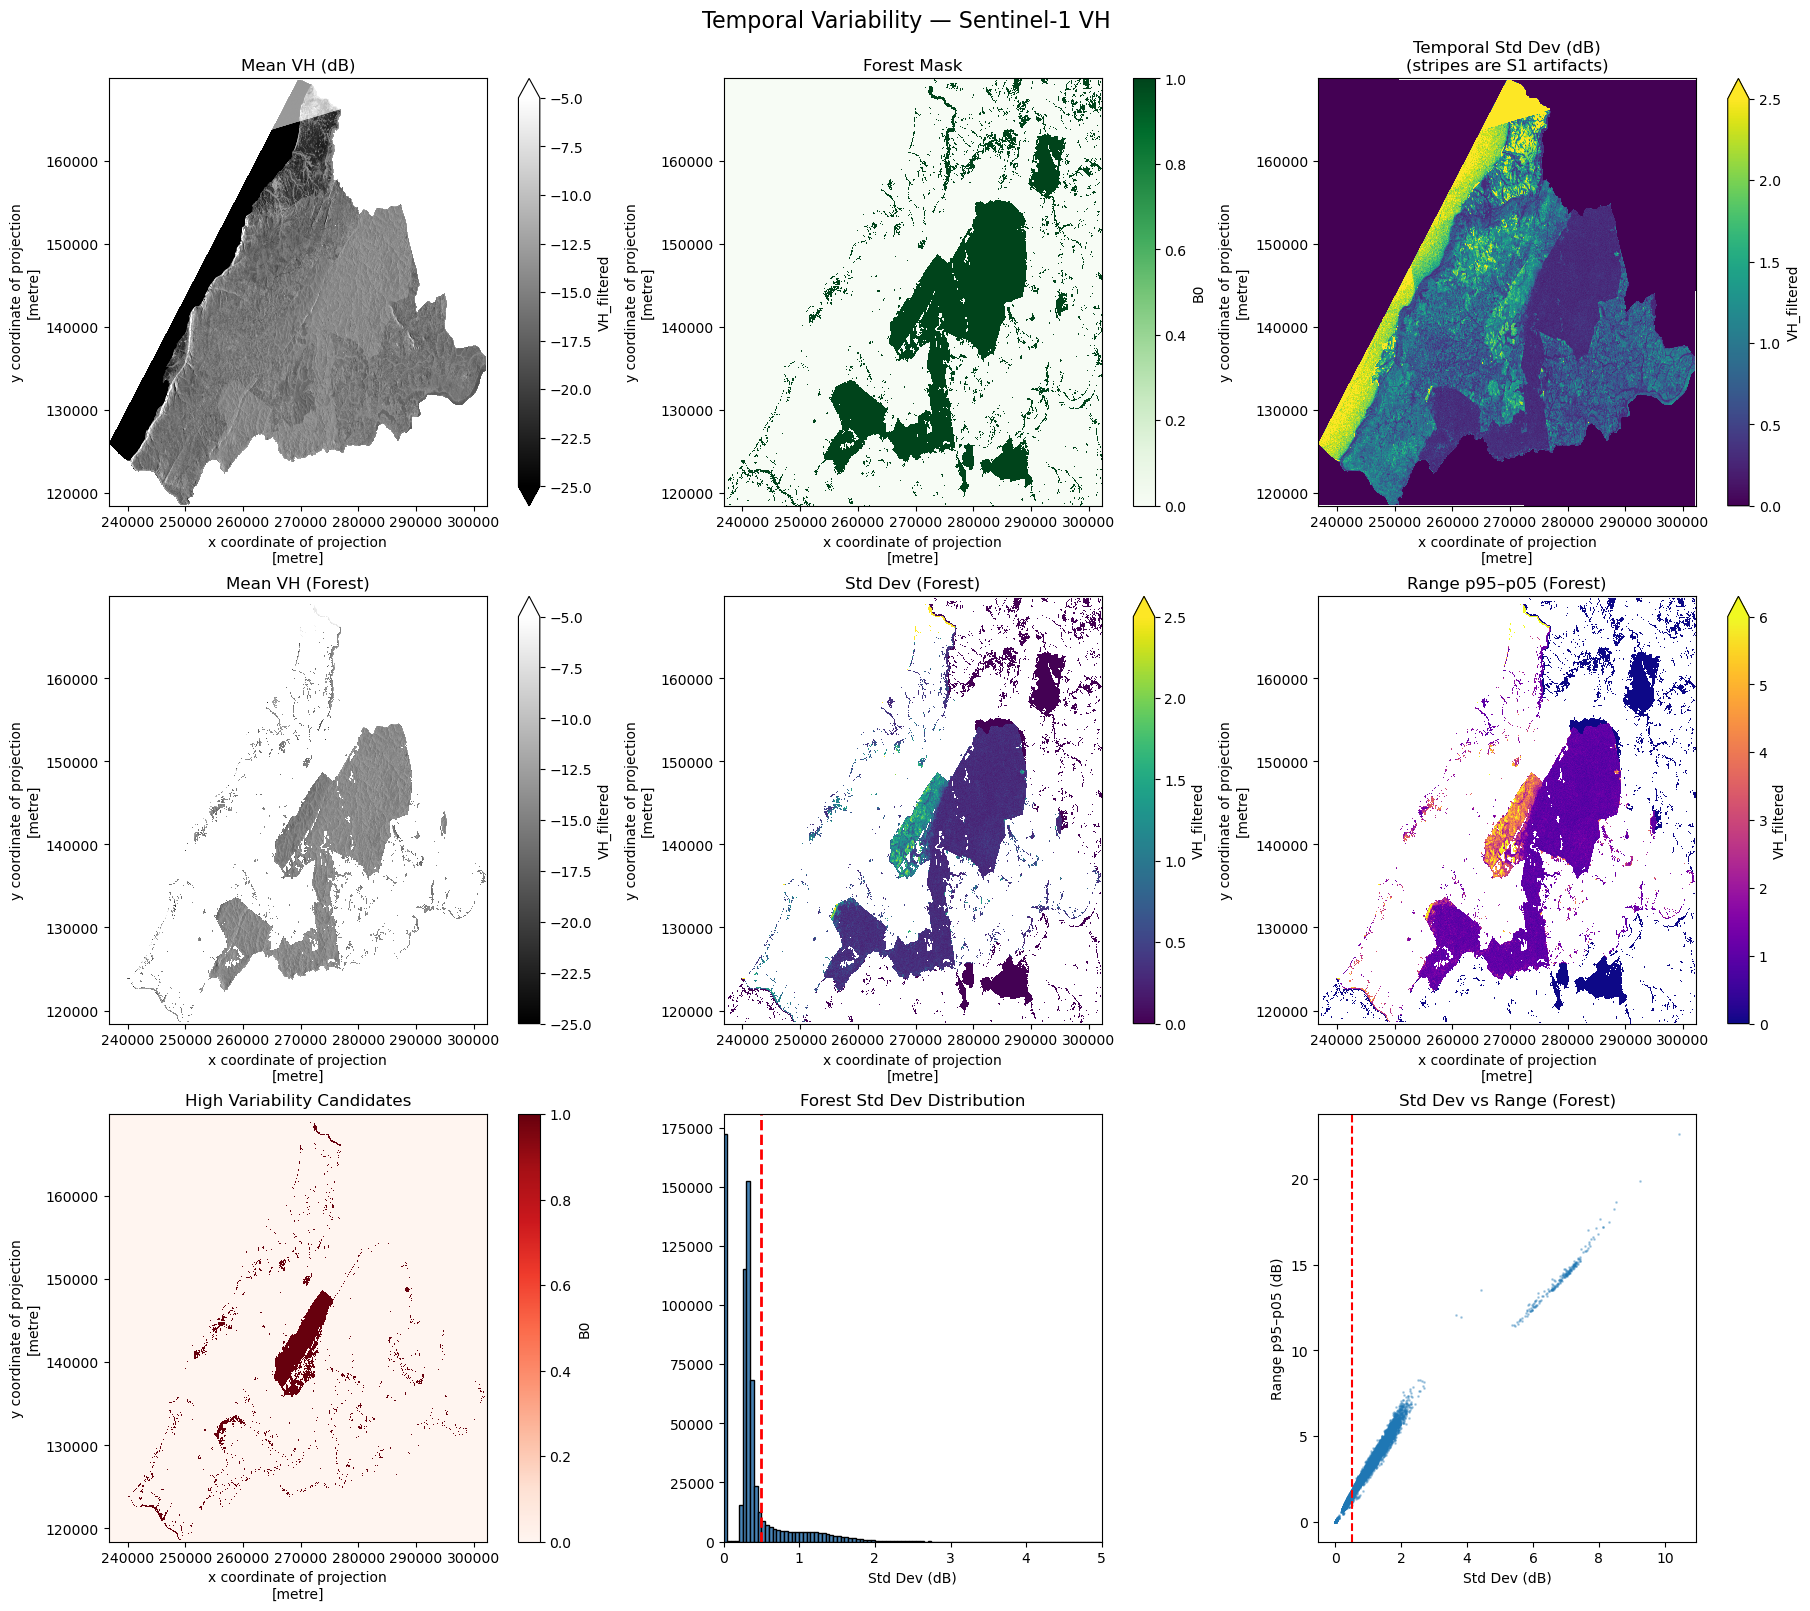


Saving results to Zarr...
✓ Saved: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_temporal_variability_k5.zarr


/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [4]:
"""
Temporal Variability Analysis
==========================================
Work in native S1 grid
Accept horizontal striping (inherent to GEE S1)
"""

# ===================== CONFIG =====================
ZARR_IN = base_path + "s1_timeseries/s1_filtered_k5.zarr"
FOREST_MASK_TIF = base_path + "forest_extent_bugoma_2020_32636.tif"


ZARR_OUT = base_path + "s1_timeseries/s1_temporal_variability_k5.zarr"

USE_FIXED_SIGMA = True
FIXED_THRESHOLD = 0.5      # dB
TV_PERCENTILE = 70         # if percentile-based

# ===================== LOAD DATA =====================
print("=" * 60)
print("TEMPORAL VARIABILITY ANALYSIS")
print("=" * 60)

ds = xr.open_zarr(ZARR_IN, consolidated=True, chunks="auto")

# Assign correct CRS
if ds.rio.crs is None:
    ds = ds.rio.write_crs("EPSG:32636")
vh = ds["VH_filtered"]     # lazy

print(vh)
print(f"Date range: {ds.time[0].values} → {ds.time[-1].values}")

# ===================== FOREST MASK =====================
print("\nLoading forest mask...")


forest_mask = (
    rxr.open_rasterio(FOREST_MASK_TIF)   
       .squeeze("band", drop=True)       
       .rio.reproject_match(ds)          
       .astype(bool)
)

forest_mask = forest_mask.compute()      
print(
    f"✓ Forest pixels: {forest_mask.sum().item():,} "
    f"({forest_mask.mean().item() * 100:.1f}%)"
)


# ===================== TEMPORAL STATISTICS (DASK) =====================
print("\nCalculating temporal statistics (lazy)...")

std_dev = vh.std(dim="time", skipna=True)
mean_vh = vh.mean(dim="time", skipna=True)
p05 = vh.quantile(0.05, dim="time", skipna=True)
p95 = vh.quantile(0.95, dim="time", skipna=True)
range_vh = p95 - p05

# Materialize once (shared downstream)
std_dev, mean_vh, p05, p95, range_vh = compute(std_dev, mean_vh, p05, p95, range_vh)
p05 = p05.drop_vars("quantile")
p95 = p95.drop_vars("quantile")

print("✓ Statistics computed")

# ===================== FOREST-ONLY STATS =====================
forest_std = std_dev.where(forest_mask)
forest_range = range_vh.where(forest_mask)

print(f"Forest std dev: {forest_std.min():.3f} → {forest_std.max():.3f} dB")
print(f"Mean forest std dev: {forest_std.mean():.3f} dB")

# ===================== THRESHOLDING =====================
print("\n" + "=" * 60)
print("CANDIDATE SELECTION")
print("=" * 60)

if USE_FIXED_SIGMA:
    tv_threshold = FIXED_THRESHOLD
    candidate_mask = (std_dev >= tv_threshold) & forest_mask
    percentile_equiv = (
        (forest_std < tv_threshold).sum() / forest_std.count() * 100
    ).item()

    print(f"✓ Fixed threshold: {tv_threshold:.3f} dB")
    print(f"  Equivalent percentile: p{percentile_equiv:.1f}")

else:
    tv_threshold = forest_std.quantile(TV_PERCENTILE / 100).item()
    candidate_mask = (std_dev >= tv_threshold) & forest_mask
    print(f"✓ Percentile threshold: p{TV_PERCENTILE} → {tv_threshold:.3f} dB")

print(f"Candidates: {candidate_mask.sum().item():,} "
      f"({candidate_mask.mean().item() * 100:.1f}%)")

# ===================== VISUALIZATION =====================
fig, axes = plt.subplots(3, 3, figsize=(18, 16), constrained_layout=True)

# Row 1
mean_vh.plot(ax=axes[0, 0], cmap="gray", vmin=-25, vmax=-5)
axes[0, 0].set_title("Mean VH (dB)")

forest_mask.plot(ax=axes[0, 1], cmap="Greens")
axes[0, 1].set_title("Forest Mask")

std_dev.plot(ax=axes[0, 2], cmap="viridis", vmin=0, vmax=2.5)
axes[0, 2].set_title("Temporal Std Dev (dB)\n(stripes are S1 artifacts)")

# Row 2
mean_vh.where(forest_mask).plot(ax=axes[1, 0], cmap="gray", vmin=-25, vmax=-5)
axes[1, 0].set_title("Mean VH (Forest)")

std_dev.where(forest_mask).plot(ax=axes[1, 1], cmap="viridis", vmin=0, vmax=2.5)
axes[1, 1].set_title("Std Dev (Forest)")

range_vh.where(forest_mask).plot(ax=axes[1, 2], cmap="plasma", vmin=0, vmax=6)
axes[1, 2].set_title("Range p95–p05 (Forest)")

# Row 3
candidate_mask.plot(ax=axes[2, 0], cmap="Reds")
axes[2, 0].set_title("High Variability Candidates")

# Flatten and remove NaNs + outliers before plotting
forest_std_vals = forest_std.values.flatten()
forest_std_vals = forest_std_vals[np.isfinite(forest_std_vals)]
forest_std_vals = forest_std_vals[forest_std_vals < 5]  # clip tail — adjust if needed

axes[2, 1].hist(
    forest_std_vals,
    bins=100,
    color="steelblue",
    edgecolor="black"
)
axes[2, 1].axvline(tv_threshold, color="red", linestyle="--", linewidth=2)
axes[2, 1].set_title("Forest Std Dev Distribution")
axes[2, 1].set_xlabel("Std Dev (dB)")
axes[2, 1].set_xlim(0, 5)  # focus on meaningful range


axes[2, 2].scatter(
    forest_std.values[::10],
    forest_range.values[::10],
    s=1,
    alpha=0.3
)
axes[2, 2].axvline(tv_threshold, color="red", linestyle="--")
axes[2, 2].set_xlabel("Std Dev (dB)")
axes[2, 2].set_ylabel("Range p95–p05 (dB)")
axes[2, 2].set_title("Std Dev vs Range (Forest)")

plt.suptitle("Temporal Variability — Sentinel‑1 VH", fontsize=16)
plt.show()

# ===================== SAVE RESULTS (ZARR) =====================
print("\nSaving results to Zarr...")

ds_out = xr.Dataset(
    {
        "std_dev":        std_dev,
        "mean_vh":        mean_vh,
        "p05":            p05,       # ← add
        "p95":            p95,       # ← add
        "range_vh":       range_vh,
        "forest_mask":    forest_mask,
        "candidate_mask": candidate_mask,
    },
    coords={"x": ds.x, "y": ds.y},
    attrs={
        "description": "Temporal variability metrics for change detection",
        "tv_threshold": float(tv_threshold),
        "threshold_method": "fixed" if USE_FIXED_SIGMA else "percentile",
        "note": "Horizontal stripes are inherent Sentinel‑1 GEE artifacts",
    }
)

ds_out.to_zarr(ZARR_OUT, mode="w", consolidated=True)
print(f"✓ Saved: {ZARR_OUT}")

## Logistic Fitting

In [5]:
"""
LOGISTIC FITTING — NUMBA + ZARR TILED I/O
=========================================
Fits logistic curves on candidate pixels to estimate deforestation timing.
- Reads filtered VH from Zarr lazily
- Uses Numba to accelerate pixel-level fitting
- Processes in spatial tiles aligned with chunks for fast I/O
- FLAT_THRESH   = 0.12  — adjustable; filters pixels with weak backscatter change
- SSE thresholds at p95/p98/p99 — higher percentile permits more sigmoid shapes
- Saves outputs to Zarr (consolidated)
"""

# ===================== CONFIG =====================
ZARR_FILTERED = base_path + "s1_timeseries/s1_filtered_k5.zarr"
ZARR_TV       = base_path + "s1_timeseries/s1_temporal_variability_k5.zarr"
ZARR_OUT      = base_path + "s1_timeseries/s1_logistic_fitting_k5.zarr"

A_STEEPNESS = -2.0   # logistic steepness (negative: drop)
N_WINDOW    = 5      # +/- images around candidate t0
FLAT_THRESH = 0.12   # flattening threshold
TILE_Y      = 256    # align with Zarr chunking
TILE_X      = 256

# ===================== LOAD (LAZY) =====================
print("=" * 60)
print("LOGISTIC FITTING — NUMBA + ZARR")
print("=" * 60)

ds    = xr.open_zarr(ZARR_FILTERED, consolidated=True, chunks="auto")
ds_tv = xr.open_zarr(ZARR_TV,       consolidated=True, chunks="auto")

vh   = ds["VH_filtered"]
time = ds.time.values
ny, nx, M = ds.sizes["y"], ds.sizes["x"], ds.sizes["time"]

candidate_mask = ds_tv["candidate_mask"].compute().values.astype(bool)
forest_mask    = ds_tv["forest_mask"].compute().values.astype(bool)

print(f"time steps : {M}")
print(f"candidates : {int(candidate_mask.sum()):,}")

# ===================== BASELINE & AMPLITUDE =====================
required = {"p05", "p95"}
if not required.issubset(ds_tv.data_vars):
    missing = required - set(ds_tv.data_vars)
    raise KeyError(
        f"Temporal-variability Zarr is missing required variables: {missing}. "
        "Re-run the temporal-variability step to generate p05 and p95."
    )

p05   = ds_tv["p05"].compute().astype("float32")
p95   = ds_tv["p95"].compute().astype("float32")
amp   = (p95 - p05).astype("float32")
lower = p05

# Flattening metric
flattening = (amp / (np.abs(lower) + 1e-6)).astype("float32")

# ===================== NUMBA-ACCELERATED FIT =====================
@njit(cache=True, fastmath=True)
def fit_logistic_pixel_numba(ts, lower_v, amp_v, a, n_window, t0_candidates):
    """
    ts            : 1D float32 time series (length M)
    lower_v, amp_v: float32 scalars
    a             : float32 steepness
    n_window      : int — half-window around each candidate t0
    t0_candidates : 1D int32 array of candidate t0 indices
    Returns       : (best_t0 as float32, best_sse as float32); best_t0=NaN if no fit
    """
    M = ts.size
    best_sse = np.float32(1e30)
    best_t0  = np.float32(np.nan)

    for t0 in t0_candidates:
        sse = np.float32(0.0)
        for t in range(max(0, t0 - n_window), min(M, t0 + n_window + 1)):
            exp_arg = max(-50.0, min(50.0, -a * (t - t0)))
            pred    = amp_v / (1.0 + np.exp(exp_arg)) + lower_v
            val     = ts[t]
            if not np.isnan(val):
                sse += (val - pred) ** 2

        if sse < best_sse:
            best_sse = sse
            best_t0  = np.float32(t0)

    return best_t0, best_sse

t0_candidates = np.arange(N_WINDOW, M - N_WINDOW, dtype=np.int32)

# ===================== OUTPUT ARRAYS =====================
best_t0  = np.full((ny, nx), np.nan, dtype=np.float32)
best_sse = np.full((ny, nx), np.nan, dtype=np.float32)

# ===================== TILED PROCESSING =====================
print("\nFitting (tiled, Numba-accelerated)...")
total_cand = int(candidate_mask.sum())
flat_vals  = flattening.values
done = 0

for y0 in range(0, ny, TILE_Y):
    y1 = min(y0 + TILE_Y, ny)
    for x0 in range(0, nx, TILE_X):
        x1 = min(x0 + TILE_X, nx)

        valid_tile = candidate_mask[y0:y1, x0:x1] & (flat_vals[y0:y1, x0:x1] >= FLAT_THRESH)
        if not valid_tile.any():
            continue

        block       = vh.isel(y=slice(y0, y1), x=slice(x0, x1)).values  # (time, ty, tx)
        block_lower = lower.values[y0:y1, x0:x1]
        block_amp   = amp.values[y0:y1, x0:x1]

        for ii, jj in zip(*np.where(valid_tile)):
            ts = block[:, ii, jj].astype(np.float32, copy=False)
            if np.count_nonzero(~np.isnan(ts)) < 0.5 * M:
                continue

            best_t0[y0 + ii, x0 + jj], best_sse[y0 + ii, x0 + jj] = fit_logistic_pixel_numba(
                ts, np.float32(block_lower[ii, jj]), np.float32(block_amp[ii, jj]),
                np.float32(A_STEEPNESS), np.int32(N_WINDOW), t0_candidates,
            )

        done += int(valid_tile.sum())
        if done % 5000 == 0:
            print(f"  {done:,}/{total_cand:,} ({done/total_cand*100:.1f}%)")

print(f"✓ Valid fits: {int(np.isfinite(best_t0).sum()):,}")

# ===================== t0 → YEAR.FRACTION (vectorised) =====================
print("\nConverting t0 to year.fraction...")
defor_years = np.full((ny, nx), np.nan, dtype=np.float32)

finite_mask = np.isfinite(best_t0)
t0_idx      = best_t0[finite_mask].astype(int)
timestamps  = pd.DatetimeIndex(time[t0_idx])
doy         = timestamps.day_of_year.to_numpy()
days_in_yr  = np.where(timestamps.is_leap_year, 366, 365)

defor_years[finite_mask] = timestamps.year.to_numpy() + (doy - 1) / days_in_yr

# ===================== SSE THRESHOLDS + DEFORESTATION MASKS =====================
valid_sse = best_sse[np.isfinite(best_sse)]
sse_p95, sse_p98, sse_p99 = (
    (float(np.percentile(valid_sse, p)) for p in (95, 98, 99))
    if valid_sse.size > 0 else (1e9, 1e9, 1e9)
)

SSE_THRESH = {"moderate": sse_p95, "permissive": sse_p98, "ultra-permissive": sse_p99}

base_mask    = candidate_mask & (flat_vals >= FLAT_THRESH) & np.isfinite(best_t0)
defor_masks  = {name: base_mask & (best_sse < thr) for name, thr in SSE_THRESH.items()}

print("\nSuggested SSE thresholds:")
print(f"  moderate         (p95): {sse_p95:.1f}")
print(f"  permissive       (p98): {sse_p98:.1f}")
print(f"  ultra-permissive (p99): {sse_p99:.1f}")

# ===================== SAVE RESULTS (ZARR) =====================
print("\nSaving results to Zarr...")
ds_out = xr.Dataset(
    data_vars={
        "best_t0":                    (("y", "x"), best_t0),
        "best_sse":                   (("y", "x"), best_sse),
        "flattening":                 (("y", "x"), flat_vals.astype(np.float32)),
        "amplitude":                  (("y", "x"), amp.values.astype(np.float32)),
        "defor_years":                (("y", "x"), defor_years),
        "defor_mask_moderate":        (("y", "x"), defor_masks["moderate"].astype(np.uint8)),
        "defor_mask_permissive":      (("y", "x"), defor_masks["permissive"].astype(np.uint8)),
        "defor_mask_ultra_permissive":(("y", "x"), defor_masks["ultra-permissive"].astype(np.uint8)),
    },
    coords={"x": ds.x, "y": ds.y},
    attrs={
        "description": "Logistic fitting for deforestation timing",
        "crs":         "EPSG:32636",
        "a_steepness": A_STEEPNESS,
        "n_window":    N_WINDOW,
        "flat_threshold": FLAT_THRESH,
        "sse_p95": sse_p95, "sse_p98": sse_p98, "sse_p99": sse_p99,
    },
)
ds_out.to_zarr(ZARR_OUT, mode="w", consolidated=True)
print(f"✓ Saved: {ZARR_OUT}")

LOGISTIC FITTING — NUMBA + ZARR
time steps : 152
candidates : 104,746

Fitting (tiled, Numba-accelerated)...
✓ Valid fits: 91,731

Converting t0 to year.fraction...

Suggested SSE thresholds:
  moderate         (p95): 18.3
  permissive       (p98): 165.8
  ultra-permissive (p99): 922.4

Saving results to Zarr...
✓ Saved: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_logistic_fitting_k5.zarr


/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Compare to Hansen

HANSEN COMPARISON - ALL SSE THRESHOLDS
Extent (centers): [236743.168, 302293.134] x [118430.848, 169880.822]
Resolution: 30.000 x 30.000
CRS: EPSG:32636

Your detections:
  Moderate    : 87,144 pixels
  Permissive  : 89,896 pixels
  Ultra-permissive: 90,813 pixels

Loading Hansen (2020–2024)...
✓ Hansen 2020–2024: 118,460 pixels

VALIDATION METRICS FOR ALL THRESHOLDS

MODERATE:
  Your detections:   87,144 pixels
  Agreement (TP):    60,763 pixels
  Commission (FP):   26,381 pixels
  Omission (FN):     57,697 pixels
  Precision:          69.7%
  Recall:             51.3%
  F1 Score:           59.1%

PERMISSIVE:
  Your detections:   89,896 pixels
  Agreement (TP):    63,140 pixels
  Commission (FP):   26,756 pixels
  Omission (FN):     55,320 pixels
  Precision:          70.2%
  Recall:             53.3%
  F1 Score:           60.6%

ULTRA-PERMISSIVE:
  Your detections:   90,813 pixels
  Agreement (TP):    63,166 pixels
  Commission (FP):   27,647 pixels
  Omission (FN):     55,294 pixels

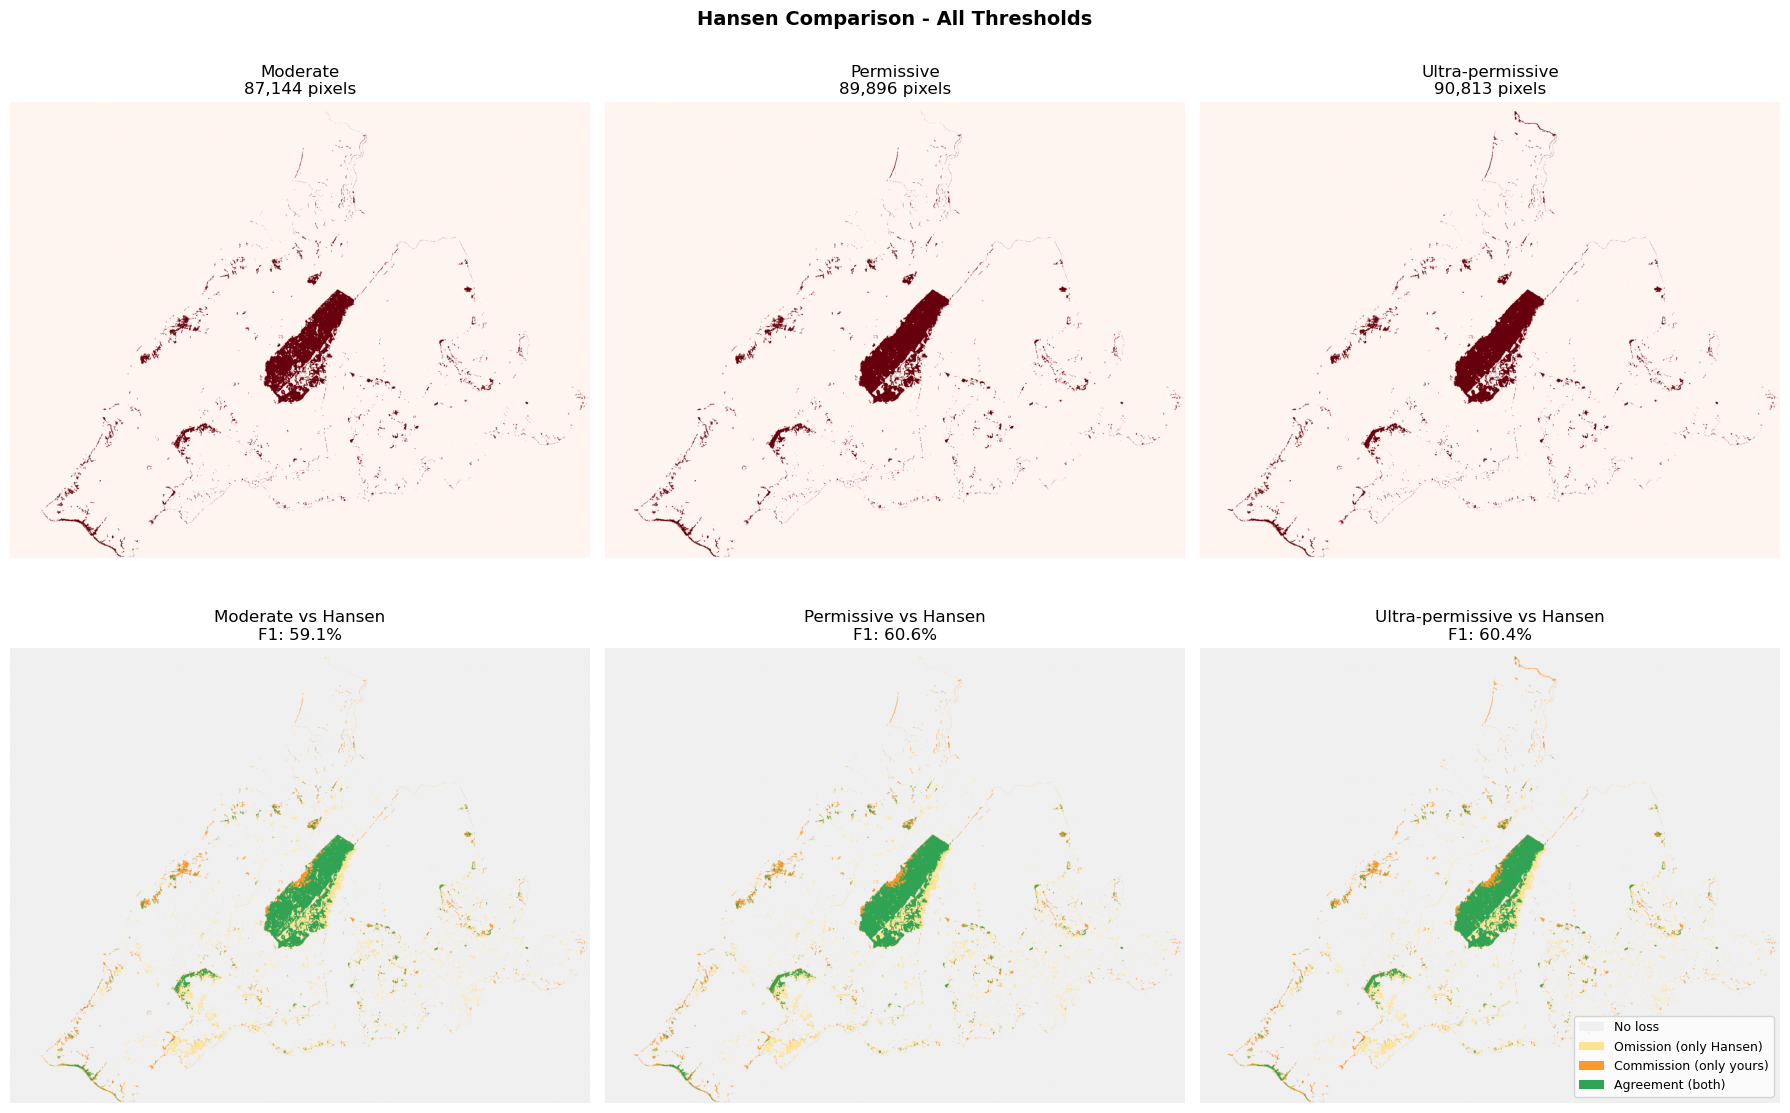

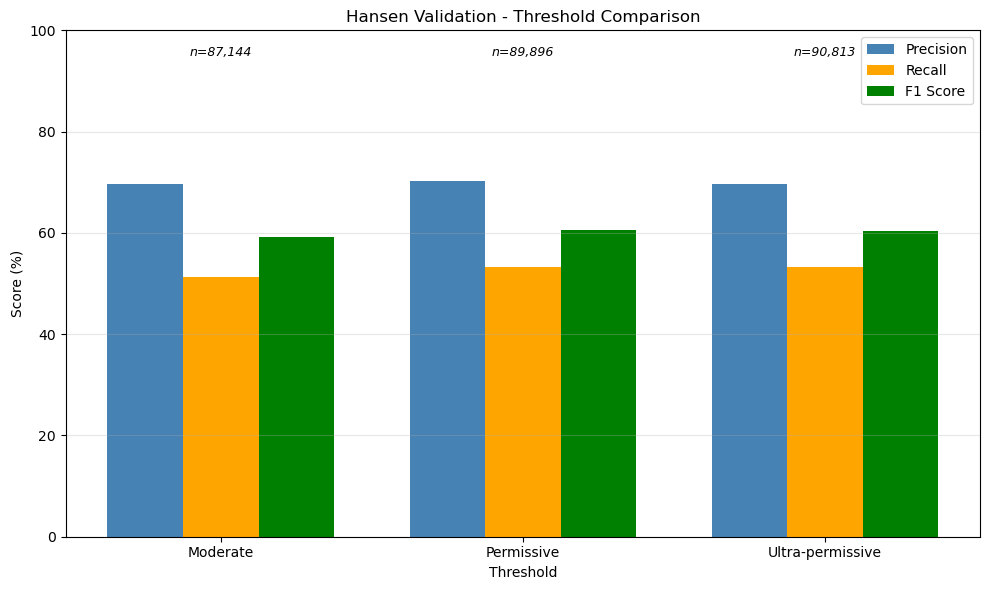


RECOMMENDATION
Best F1 score: PERMISSIVE (60.6%)
  Precision: 70.2%
  Recall:    53.3%


In [6]:
"""
HANSEN COMPARISON - COMPARE ALL SSE THRESHOLDS
==========================================

Compares the three deforestation masks from the logistic fitting output
against Hansen loss years 2020–2025, computes precision/recall/F1, and
renders agreement maps + summary bars. Use best map to proceed.
Allows to better understand the trade-off between stricter vs more permissive SSE thresholds
"""


# -------------------- PATHS --------------------
LOGISTIC_FILE = base_path + "s1_timeseries/s1_logistic_fitting_k5.zarr"
HANSEN_PATH   = base_path + "Hansen/hansen_bugoma_32636.tif"

# -------------------- LOAD RESULTS --------------------
print("=" * 60)
print("HANSEN COMPARISON - ALL SSE THRESHOLDS")
print("=" * 60)

if not os.path.exists(HANSEN_PATH):
    print(f"ERROR: Hansen TIFF not found at: {HANSEN_PATH}", file=sys.stderr)
    sys.exit(1)

ds = xr.open_zarr(LOGISTIC_FILE, consolidated=True)

# Map the logistic masks with fallback to older names if needed
def _get_var(ds, prefer, fallback=None):
    if prefer in ds.data_vars:
        return ds[prefer]
    if fallback and fallback in ds.data_vars:
        return ds[fallback]
    raise KeyError(f"Could not find variable '{prefer}'"
                   + (f" nor fallback '{fallback}'." if fallback else "."))

m_conservative = _get_var(ds, "defor_mask_moderate")
m_moderate     = _get_var(ds, "defor_mask_permissive", fallback="defor_mask")  # <— fallback
m_permissive   = _get_var(ds, "defor_mask_ultra_permissive")

# Convert to plain NumPy boolean arrays
masks = {
    "moderate": (m_conservative.values.astype(np.uint8) > 0),
    "permissive":     (m_moderate.values.astype(np.uint8) > 0),
    "ultra-permissive":   (m_permissive.values.astype(np.uint8) > 0),
}

# Spatial metadata from the Zarr grid
x = ds["x"].values
y = ds["y"].values
x_min, x_max = float(np.min(x)), float(np.max(x))
y_min, y_max = float(np.min(y)), float(np.max(y))

# infer resolution from coords (assumed to be pixel centers)
if x.size < 2 or y.size < 2:
    print("ERROR: Not enough coordinates to infer resolution.", file=sys.stderr)
    sys.exit(1)

res_x = float(np.mean(np.diff(x)))
res_y = float(np.mean(np.diff(y)))
res_x = abs(res_x)
res_y = abs(res_y)

# Build bounds with half-pixel padding (to match from_bounds semantics)
left   = x_min - res_x / 2.0
right  = x_max + res_x / 2.0
bottom = y_min - res_y / 2.0
top    = y_max + res_y / 2.0

height, width = masks["moderate"].shape

# Determine target CRS (prefer dataset attribute; default to EPSG:32636)
crs_str = ds.attrs.get("crs", "EPSG:32636")
try:
    s1_crs = CRS.from_string(crs_str)
except Exception:
    s1_crs = CRS.from_epsg(32636)

s1_transform = from_bounds(left, bottom, right, top, width, height)

print(f"Extent (centers): [{x_min:.3f}, {x_max:.3f}] x [{y_min:.3f}, {y_max:.3f}]")
print(f"Resolution: {res_x:.3f} x {res_y:.3f}")
print(f"CRS: {s1_crs.to_string()}")
print("\nYour detections:")
for name, mask in masks.items():
    print(f"  {name.capitalize():12s}: {int(mask.sum()):,} pixels")

# -------------------- LOAD & REPROJECT HANSEN --------------------
print("\nLoading Hansen (2020–2024)...")

with rasterio.open(HANSEN_PATH) as src:
    # Prepare destination array (uint8 is fine for loss year classes 0..N)
    hansen_data = np.zeros((height, width), dtype=np.uint8)
    reproject(
        source=rasterio.band(src, 1),
        destination=hansen_data,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest,
    )

# Select Hansen loss years [20..24] => 2020–2024
hansen_ref = ((hansen_data >= 20) & (hansen_data <= 24)).astype(np.uint8)
print(f"✓ Hansen 2020–2024: {int(hansen_ref.sum()):,} pixels")

# -------------------- METRICS FOR ALL THRESHOLDS --------------------
print("\n" + "=" * 60)
print("VALIDATION METRICS FOR ALL THRESHOLDS")
print("=" * 60)

def _safe_pct(num, den):
    return (num / den * 100.0) if den > 0 else 0.0

results = {}

for name, your_defor in masks.items():
    your_defor_i = your_defor.astype(np.uint8)

    tp = int(np.sum((your_defor_i == 1) & (hansen_ref == 1)))
    fp = int(np.sum((your_defor_i == 1) & (hansen_ref == 0)))
    fn = int(np.sum((your_defor_i == 0) & (hansen_ref == 1)))

    precision = _safe_pct(tp, tp + fp)
    recall    = _safe_pct(tp, tp + fn)
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    results[name] = {
        "detected": int(your_defor_i.sum()),
        "tp": tp, "fp": fp, "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

    print(f"\n{name.upper()}:")
    print(f"  Your detections:  {results[name]['detected']:>7,} pixels")
    print(f"  Agreement (TP):   {tp:>7,} pixels")
    print(f"  Commission (FP):  {fp:>7,} pixels")
    print(f"  Omission (FN):    {fn:>7,} pixels")
    print(f"  Precision:        {precision:>6.1f}%")
    print(f"  Recall:           {recall:>6.1f}%")
    print(f"  F1 Score:         {f1:>6.1f}%")

# -------------------- VISUALIZATION --------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Your detections
for idx, (name, mask) in enumerate(masks.items()):
    axes[0, idx].imshow(mask, cmap="Reds")
    axes[0, idx].set_title(f"{name.capitalize()}\n{int(mask.sum()):,} pixels")
    axes[0, idx].axis("off")

# Row 2: Agreement maps
colors = ["#f0f0f0", "#fee391", "#fe9929", "#31a354"]
cmap = ListedColormap(colors)

for idx, (name, mask) in enumerate(masks.items()):
    your_defor = mask.astype(np.uint8)
    agreement = np.zeros_like(your_defor, dtype=np.uint8)
    # 0: No loss (00), 1: Omission (01), 2: Commission (10), 3: Agreement (11)
    agreement[(your_defor == 0) & (hansen_ref == 0)] = 0
    agreement[(your_defor == 0) & (hansen_ref == 1)] = 1
    agreement[(your_defor == 1) & (hansen_ref == 0)] = 2
    agreement[(your_defor == 1) & (hansen_ref == 1)] = 3

    axes[1, idx].imshow(agreement, cmap=cmap, vmin=0, vmax=3)
    axes[1, idx].set_title(f"{name.capitalize()} vs Hansen\nF1: {results[name]['f1']:.1f}%")
    axes[1, idx].axis("off")

# Legend on last subplot
legend_elements = [
    Patch(facecolor="#f0f0f0", label="No loss"),
    Patch(facecolor="#fee391", label="Omission (only Hansen)"),
    Patch(facecolor="#fe9929", label="Commission (only yours)"),
    Patch(facecolor="#31a354", label="Agreement (both)"),
]
axes[1, 2].legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.suptitle("Hansen Comparison - All Thresholds", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

# -------------------- METRICS SUMMARY PLOT --------------------
fig, ax = plt.subplots(figsize=(10, 6))

threshold_names = list(results.keys())  # ['conservative','moderate','permissive']
precision_vals = [results[k]["precision"] for k in threshold_names]
recall_vals    = [results[k]["recall"]    for k in threshold_names]
f1_vals        = [results[k]["f1"]        for k in threshold_names]

x = np.arange(len(threshold_names))
width = 0.25

ax.bar(x - width, precision_vals, width, label="Precision", color="steelblue")
ax.bar(x,         recall_vals,    width, label="Recall",    color="orange")
ax.bar(x + width, f1_vals,        width, label="F1 Score",  color="green")

ax.set_xlabel("Threshold")
ax.set_ylabel("Score (%)")
ax.set_title("Hansen Validation - Threshold Comparison")
ax.set_xticks(x)
ax.set_xticklabels([n.capitalize() for n in threshold_names])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 100)

for i, name in enumerate(threshold_names):
    ax.text(i, 95, f"n={results[name]['detected']:,}", ha="center", fontsize=9, style="italic")

plt.tight_layout()
plt.show()

# -------------------- RECOMMENDATION --------------------
print("\n" + "=" * 60)
print("RECOMMENDATION")
print("=" * 60)
best_threshold = max(results.keys(), key=lambda k: results[k]["f1"])
print(f"Best F1 score: {best_threshold.upper()} ({results[best_threshold]['f1']:.1f}%)")
print(f"  Precision: {results[best_threshold]['precision']:.1f}%")
print(f"  Recall:    {results[best_threshold]['recall']:.1f}%")

## Post-processing
to adhere to Uganda forest definition all forest patches <1ha are assigned as deforested. Deforestation dates are assigned of the closest pixel

In [14]:
# Remove small patches year-by-year and update deforestation years accordingly

import numpy as np
import xarray as xr
import rioxarray as rxr
import scipy.ndimage as ndi

# ===================== INPUTS =====================
LOGISTIC_FILE   = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_logistic_fitting_k5.zarr"
FOREST_MASK_TIF = base_path + "forest_extent_bugoma_2020_32636.tif"
PATCH_THRESH_M2 = 10_000.0                    # 1 ha — Uganda forest definition
CONNECTIVITY    = np.ones((3, 3), dtype=bool) # 8-connected

# ===================== LOAD DATA =====================
ds = xr.open_zarr(LOGISTIC_FILE, consolidated=True)

perm_mask   = ds["defor_mask_moderate"].values.astype(bool)
defor_years = ds["defor_years"].values.astype(np.float32)

forest0 = (
    rxr.open_rasterio(FOREST_MASK_TIF)
       .squeeze(drop=True)
       .rio.reproject_match(ds)
       .astype(bool)
       .compute()
       .values
)

# Pixel area in m² (EPSG:32636 → metres)
pix_area = abs(np.mean(np.diff(ds["x"].values))) * abs(np.mean(np.diff(ds["y"].values)))
print(f"Pixel area: {pix_area:.1f} m²  ({pix_area/10_000:.4f} ha)")
print(f"Patch threshold: {PATCH_THRESH_M2/10_000:.1f} ha  ({int(PATCH_THRESH_M2/pix_area)} pixels)")

# ===================== YEARS TO PROCESS =====================
finite_years = defor_years[np.isfinite(defor_years)]
if finite_years.size == 0:
    raise ValueError("No finite deforestation dates found — check logistic fitting output.")

years = np.arange(int(finite_years.min()), int(finite_years.max()) + 1)
print(f"Processing years: {years[0]} → {years[-1]}")
print(f"Initial forest: {forest0.sum():,} px  ({forest0.sum() * pix_area / 10_000:.0f} ha)")

# ===================== STATE ARRAYS =====================
forest_current  = forest0.copy()
defor_final     = np.zeros_like(forest0, dtype=bool)
defor_years_out = np.full_like(defor_years, np.nan, dtype=np.float32)

# Pre-compute valid deforestation pixels once (doesn't change across years)
valid_defor = perm_mask & np.isfinite(defor_years)

# ===================== YEARLY UPDATE LOOP =====================
print("\nYear-by-year forest update:")
print(f"{'Year':<6} {'Direct loss (px)':<20} {'Fragment loss (px)':<20} {'Remaining forest (ha)'}")
print("-" * 70)

for Y in years:
    # pixels deforested *during* year Y: year.fraction in [Y, Y+1)
    new_loss = forest_current & valid_defor & (defor_years >= Y) & (defor_years < Y + 1)

    # Remaining forest after direct loss
    forest_candidate = forest_current & ~new_loss

    # Connected components — find sub-1ha fragments
    labels, _ = ndi.label(forest_candidate, structure=CONNECTIVITY)
    patch_areas = np.bincount(labels.ravel()) * pix_area
    small_ids   = np.where(
        (patch_areas < PATCH_THRESH_M2) & (np.arange(patch_areas.size) != 0)
    )[0]
    forced_loss = np.isin(labels, small_ids) & forest_candidate

    # Update state
    forest_current   = forest_candidate & ~forced_loss
    defor_final     |= new_loss | forced_loss
    defor_years_out[new_loss    & ~np.isfinite(defor_years_out)] = float(Y)
    defor_years_out[forced_loss & ~np.isfinite(defor_years_out)] = float(Y)

    print(
        f"{Y:<6} {new_loss.sum():<20,} {forced_loss.sum():<20,} "
        f"{forest_current.sum() * pix_area / 10_000:.1f}"
    )

# ===================== SUMMARY =====================
print("\n✓ Done")
print(f"Final forest:      {forest_current.sum():,} px  ({forest_current.sum() * pix_area / 10_000:.0f} ha)")
print(f"Total deforested:  {defor_final.sum():,} px  ({defor_final.sum() * pix_area / 10_000:.0f} ha)")
print(f"Finite dates:      {np.isfinite(defor_years_out).sum():,} px")

# Sanity check — no pixel should be both forest and deforested
assert not (forest_current & defor_final).any(), "Overlap between forest and deforested pixels!"

# ===================== OUTPUT DATASET =====================
out = xr.Dataset(
    data_vars={
        "forest_extent":     (("y", "x"), forest_current.astype(np.uint8)),
        "defor_mask":        (("y", "x"), defor_final.astype(np.uint8)),
        "defor_years_final": (("y", "x"), defor_years_out),
    },
    coords={"x": ds["x"], "y": ds["y"]},
    attrs={
        "crs":                ds.attrs.get("crs", "EPSG:32636"),
        "patch_threshold_m2": PATCH_THRESH_M2,
        "pixel_area_m2":      pix_area,
        "method": (
            "Year-wise forest extent update. Forest monotonically reduced using "
            "deforestation dates from logistic fitting. Sub-1ha connected patches "
            "removed at each annual step per Uganda forest definition. "
            "Fragmentation-loss pixels assigned the year they fell below threshold."
        ),
    },
)

# out.to_zarr("/path/to/yearly_forest_update.zarr", mode="w", consolidated=True)

Pixel area: 900.0 m²  (0.0900 ha)
Patch threshold: 1.0 ha  (11 pixels)
Processing years: 2020 → 2024
Initial forest: 666,772 px  (60009 ha)

Year-by-year forest update:
Year   Direct loss (px)     Fragment loss (px)   Remaining forest (ha)
----------------------------------------------------------------------
2020   3,253                1,565                59575.8
2021   11,093               893                  58497.1
2022   26,838               2,382                55867.3
2023   28,715               2,422                53064.9
2024   12,868               839                  51831.3

✓ Done
Final forest:      575,904 px  (51831 ha)
Total deforested:  90,868 px  (8178 ha)
Finite dates:      90,868 px


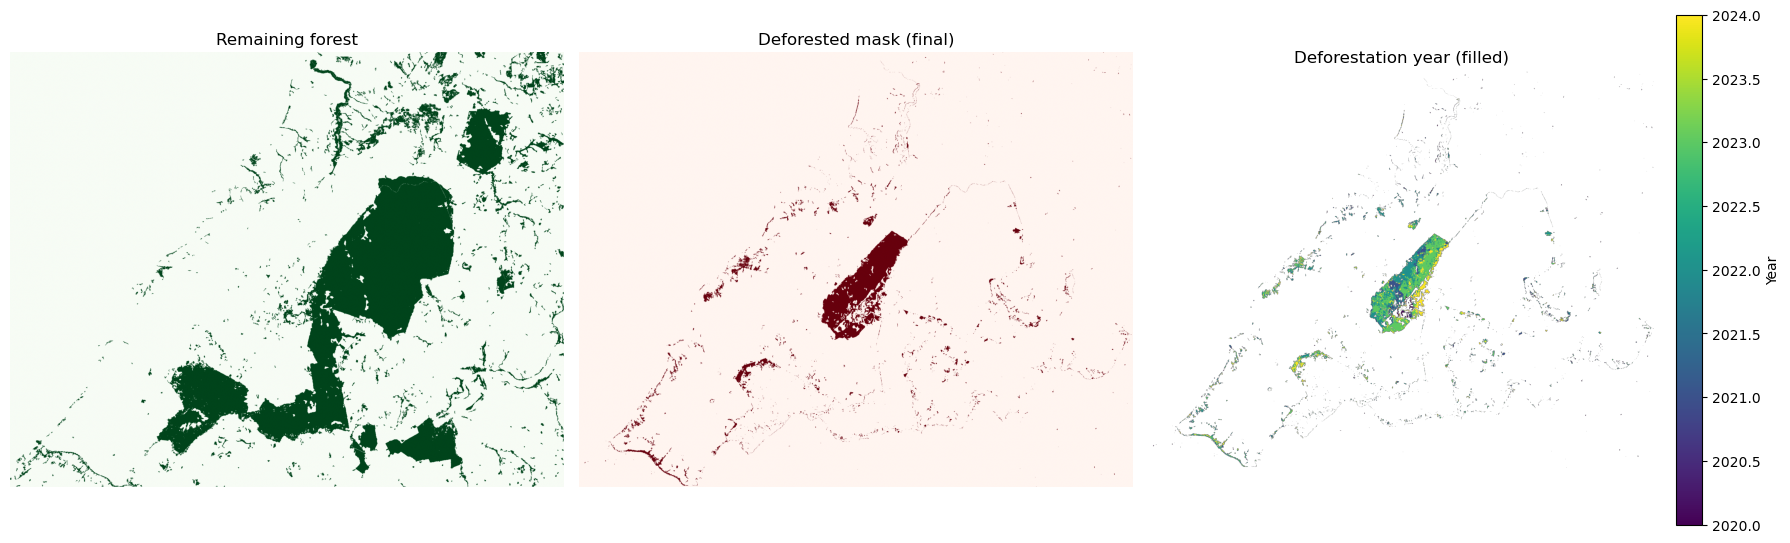

In [15]:
# Visualise
layers = {
    "Remaining forest": out["forest_extent"].values.astype(bool),
    "Deforested mask":  out["defor_mask"].values.astype(bool),
    "Deforestation year (filled)": out["defor_years_final"].values,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Remaining forest
axes[0].imshow(layers["Remaining forest"], cmap="Greens", vmin=0, vmax=1)
axes[0].set_title("Remaining forest")
axes[0].axis("off")

# 2) Deforested mask
axes[1].imshow(layers["Deforested mask"], cmap="Reds", vmin=0, vmax=1)
axes[1].set_title("Deforested mask (final)")
axes[1].axis("off")

# 3) Deforestation year (masked to deforested only for clarity)
years_to_plot = np.where(layers["Deforested mask"], layers["Deforestation year (filled)"], np.nan)
im = axes[2].imshow(years_to_plot, cmap="viridis")
axes[2].set_title("Deforestation year (filled)")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Year")

plt.tight_layout()
plt.show()

In [16]:
#__Save final output__##

OUT_DIR = base_path + "s1_deforested"
os.makedirs(OUT_DIR, exist_ok=True)

# Ensure CRS is written
CRS = "EPSG:32636"
out = out.rio.write_crs(CRS, inplace=False)

# 1) Remaining forest
out["forest_extent"].rio.to_raster(
    os.path.join(OUT_DIR, "forest_extent_2024.tif"),
    compress="LZW",
    dtype="uint8"
)

# 2) Final deforested mask
out["defor_mask"].rio.to_raster(
    os.path.join(OUT_DIR, "s1_deforestation_mask_20-25.tif"),
    compress="LZW",
    dtype="uint8"
)

# 3) Deforestation year (filled)
out["defor_years_final"].rio.to_raster(
    os.path.join(OUT_DIR, "s1_deforestation_year_20-25.tif"),
    compress="LZW",
    dtype="float32",
    nodata=np.nan
)

print("✓ GeoTIFFs saved to:", OUT_DIR)

✓ GeoTIFFs saved to: /home/georg/data/LEON_P6_forest-agri-change/s1_deforested
